In [1]:
 %tensorflow_version 2.x  
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import models

import os
import tensorflow as tf
import numpy as np
from numpy import expand_dims
import matplotlib.pyplot as plt



TensorFlow 2.x selected.


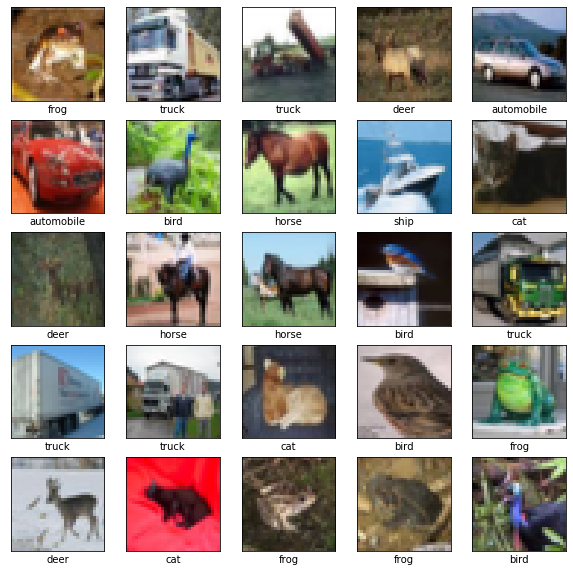

Train data Shape:(50000, 32, 32, 3)
Train label shape:(50000, 1)


In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

print("Train data Shape:"+ str(train_images.shape)) #50000 images of 32X32 pixels 3 channels(RGB)
print("Train label shape:"+ str(train_labels.shape))
data = tf.data.Dataset.from_tensor_slices(
    (train_images.reshape([-1, 32, 32, 3]).astype(np.float32), train_labels.reshape((-1,)).astype(np.int32)))
data = data.shuffle(buffer_size=50000).batch(128).repeat()

# note: we batch the test data, but do not shuffle/repeat
test_data = tf.data.Dataset.from_tensor_slices(
    (test_images.reshape([-1, 32, 32, 3]).astype(np.float32), test_labels.reshape((-1,)).astype(np.int32))).batch(128)


In [0]:
#Model with dropouts and batch_normalisation to avoid overfitting
def Model(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.1), #Addition of layer here
                
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.1), #Addition of layer here
                
                  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.25), #Addition of layer here
                  
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(256, activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Dropout(0.5),
                  tf.keras.layers.Dense(10, activation= 'softmax')]  

  model = tf.keras.Sequential(layer_list)
  return model

In [0]:
def plotAccuracies(history):  
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.5, 1])
    plt.legend(loc='upper right')
    plt.show()
    

In [0]:
def plotLosses(history):  
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

In [0]:
def run_model(model):
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  history = model.fit(train_images, train_labels, epochs=10, batch_size= 128, 
                    validation_data=(test_images, test_labels))
  plotLosses(history)
  plotAccuracies(history)

In [0]:
def train():
  for step, (img_batch, lbl_batch) in enumerate(data):
      if step > train_steps:
          break

      # print("Image_batch shape:"+ str(img_batch.shape)+ " lbl_batch shape:"+ str(lbl_batch.shape))
      with tf.GradientTape() as tape:
         logits = model(img_batch)
          # loss format is generally: first argument targets, second argument outputs
         xent = loss_fn(lbl_batch, logits)

      varis = model.trainable_variables
      grads = tape.gradient(xent, varis)

      opt.apply_gradients(zip(grads, varis))
    
      train_acc_metric(lbl_batch, logits)
    
      if not step % 200:
          # this is different from before. there, we only evaluated accuracy
         # for one batch. Now, we always average over 100 batches
         print("Step: {} Loss: {} Accuracy: {}".format(step, xent, train_acc_metric.result()))
         train_acc_metric.reset_states()


In [0]:
def test(): 
    test_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for img_batch, lbl_batch in test_data:
         test_acc_metric(lbl_batch, model(img_batch))
    print("Test acc: {}".format(test_acc_metric.result()))
    test_acc_metric.reset_states()


In [0]:
def test_with_adversarial_examples(): 
    test_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for img_batch, lbl_batch in test_data:
         test_acc_metric(lbl_batch, model(create_adversarial_examples(img_batch,lbl_batch)))
    print("Test with adversarial_examples acc: {}".format(test_acc_metric.result()))
    test_acc_metric.reset_states()

In [0]:
def create_adversarial_examples(images,labels):
  with tf.GradientTape() as tape:
    tape.watch(images)
    logits = model(images)
    xent = loss_fn(labels, logits)

  # Get the gradients of the loss w.r.t to the input image.
  gradient = tape.gradient(xent, images)
  # Get the sign of the gradients to create the perturbation
  signed_grad = tf.sign(gradient)
  plt.imshow(signed_grad[0])
  epsilon = 0.01

  adv_x = images + epsilon * signed_grad
  adv_x = tf.clip_by_value(adv_x, 0, 1)
  return adv_x

In [0]:
train_steps = 5000
opt = tf.optimizers.Adam()
loss_fn = tf.losses.SparseCategoricalCrossentropy(from_logits=True)
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()


Step: 0 Loss: 2.302703857421875 Accuracy: 0.125
Step: 200 Loss: 2.2301642894744873 Accuracy: 0.24179688096046448
Step: 400 Loss: 2.036080837249756 Accuracy: 0.3804398775100708
Step: 600 Loss: 1.98738431930542 Accuracy: 0.42597657442092896
Step: 800 Loss: 1.9743235111236572 Accuracy: 0.47385722398757935
Step: 1000 Loss: 1.9532909393310547 Accuracy: 0.5050390362739563
Step: 1200 Loss: 1.9136515855789185 Accuracy: 0.5493112206459045
Step: 1400 Loss: 1.8247339725494385 Accuracy: 0.5787500143051147
Step: 1600 Loss: 1.8402549028396606 Accuracy: 0.5846117734909058
Step: 1800 Loss: 1.8317668437957764 Accuracy: 0.6271093487739563
Step: 2000 Loss: 1.7881443500518799 Accuracy: 0.6428850889205933
Step: 2200 Loss: 1.7301998138427734 Accuracy: 0.6768749952316284
Step: 2400 Loss: 1.787421464920044 Accuracy: 0.6838212013244629
Step: 2600 Loss: 1.8246591091156006 Accuracy: 0.6975781321525574
Step: 2800 Loss: 1.7566018104553223 Accuracy: 0.7087507843971252
Step: 3000 Loss: 1.7883539199829102 Accuracy: 0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Test acc: 0.7161999940872192


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Test with adversarial_examples acc: 0.3982999920845032


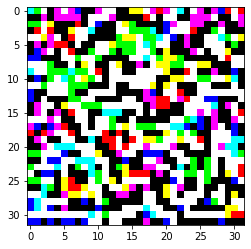

In [12]:
input_shape = (32,32,3)
model = Model(input_shape)
# run_model(model)
train()
test()
test_with_adversarial_examples()

* Test acc: 0.7161999940872192
* Test with adversarial_examples acc: 0.3982999920845032


tf.Tensor(
[3 1 8 0 6 5 1 2 5 1 4 9 4 7 9 8 5 7 8 6 1 2 4 9 4 2 4 0 9 6 6 5 4 5 9 3 4
 1 9 5 4 6 7 6 0 9 5 3 7 4 9 8 7 3 8 8 7 3 5 5 7 5 6 9 6 2 1 4 3 7 4 6 8 8
 0 2 0 5 3 8 8 9 1 7 2 7 3 0 8 9 0 3 8 6 4 6 6 0 0 7 5 5 6 3 1 1 3 6 3 5 4
 0 2 2 9 7 0 4 2 7 8 7 1 2 8 2 8 3], shape=(128,), dtype=int64)


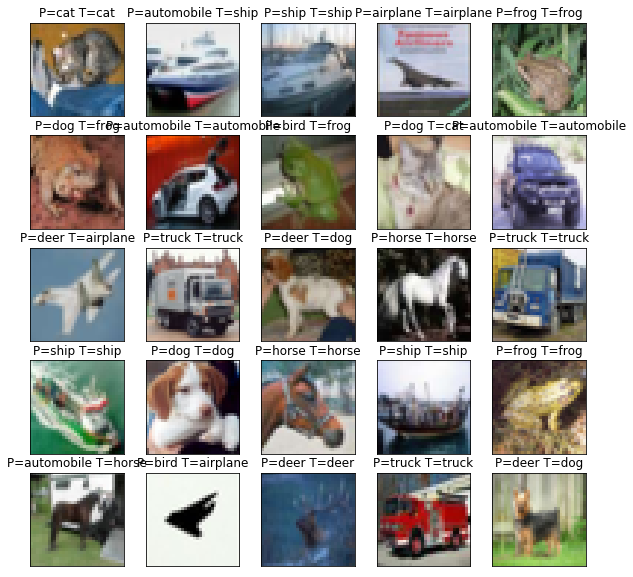

In [13]:
itr = iter(test_data)
test_batch, tlbl_batch = itr.next()
out = tf.argmax(model(test_batch),-1)
print(out)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('P={} T={}'.format(class_names[out[i]],class_names[tlbl_batch[i]]))

    plt.imshow(test_batch[i], cmap=plt.cm.binary)
plt.show()


## Adversarial examples

In [0]:
def display_images(images, labels):
  image = np.expand_dims(images[3], axis=0)
  predictions = model.predict_classes(images)
  plt.figure(figsize=(10,10))
  for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('P={} T={}'.format(class_names[predictions[i]],class_names[labels[i]]))
    plt.imshow(images[i], cmap=plt.cm.binary)
  plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


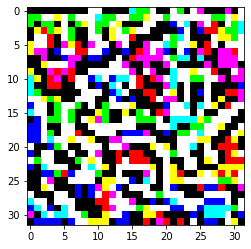

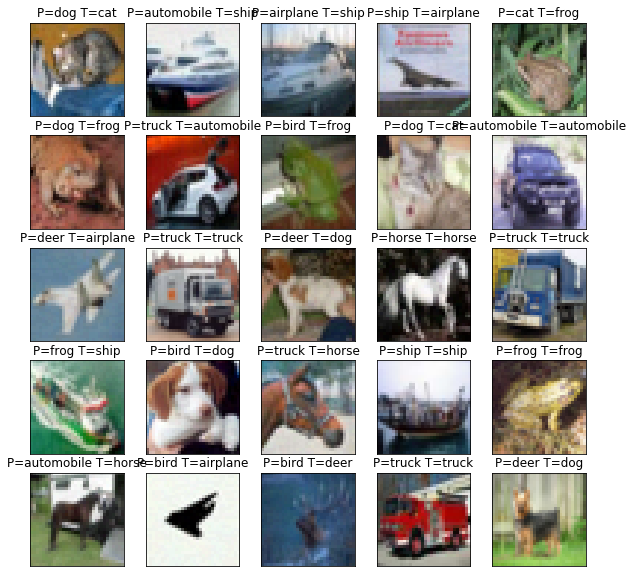

In [15]:
adv_x = create_adversarial_examples(test_batch,tlbl_batch)
display_images(adv_x,tlbl_batch)


## Advarsarial training

In [0]:
def train_double_batch():
  for step, (img_batch, lbl_batch) in enumerate(data):
      if step > train_steps:
          break

      batch = tf.concat([img_batch,create_adversarial_examples(img_batch,lbl_batch)],0)
      lbl = tf.concat([lbl_batch,lbl_batch],0)

      with tf.GradientTape() as tape:
         logits = model(batch)
          # loss format is generally: first argument targets, second argument outputs
         xent = loss_fn(lbl, logits)

      varis = model.trainable_variables
      grads = tape.gradient(xent, varis)
      opt.apply_gradients(zip(grads, varis))
      train_acc_metric(lbl, logits)
    
      if not step % 200:
          # this is different from before. there, we only evaluated accuracy
         # for one batch. Now, we always average over 100 batches
         print("Step: {} Loss: {} Accuracy: {}".format(step, xent, train_acc_metric.result()))
         train_acc_metric.reset_states()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Step: 0 Loss: 1.8434191942214966 Accuracy: 0.62109375


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Step: 200 Loss: 1.8369243144989014 Accuracy: 0.6394140720367432


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

...

Step: 5000 Loss: 1.76882004737854 Accuracy: 0.6677148342132568


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Test acc: 0.6575000286102295


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Test with adversarial_examples acc: 0.5224000215530396


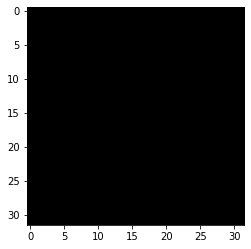

In [17]:
train_double_batch()
test()
test_with_adversarial_examples()

In [18]:
test()

Test acc: 0.6575000286102295


* Test acc: 0.6575000286102295
* Test with adversarial_examples acc: 0.5224000215530396


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


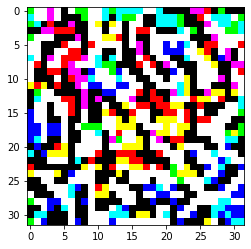

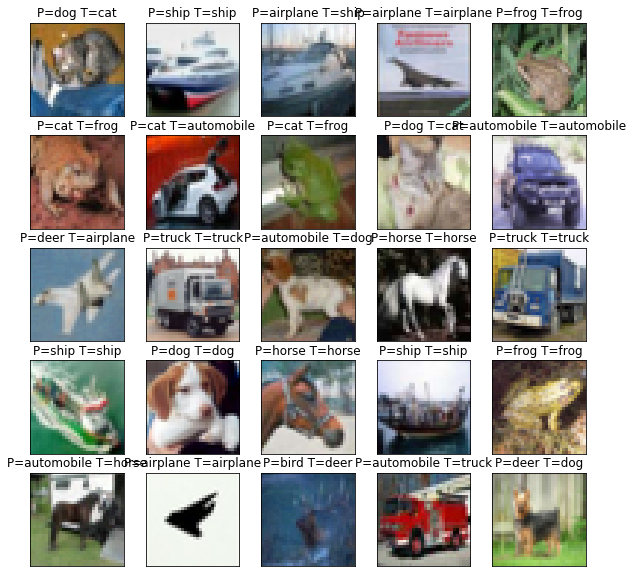

In [19]:
adv_x = create_adversarial_examples(test_batch,tlbl_batch)
display_images(adv_x,tlbl_batch)
